# Лабораторная работа. "AutoML. Построение моделей прогноза результатов обучения"
---

FC-1.1 Б Способен теоретически обосновать и осуществить на практике оптимизацию
ML-моделей по техническим показателям эффективности (быстродействие,
объем используемой памяти), используя передовые способы обучения (AutoML,
нейродинамика, алгоритмы квантования и оптимизация на уровне данных)

## Цель работы
Исследовать применимость различных методов отбора и извлечения признаков, освоить применение кросс-валидации для решения задачи построения регрессии, научиться применять autoML для улучшения моделей.

## **Описание кейса**

Для организации учебного процесса стали использоваться в большом количестве онлайн-курсы. Но без контроля и соответствующего сопровождения обучение, даже с применением онлайн-ресурсов может дать очень плачевный результат. Необходимо внедрять элементы контроля и сопровождения обучения студентов на онлайн-курсах.

Одной из таких задач построения интеллектуального тьютора онлайн-оубчения является задача прогноза конечного результата обучения на онлайн-курсе: сможет ли он успешно завершить курс и на какую оценку в зависимости от его результатов работы в первой части курса.

Эту задачу можно решать разными способами.
1. Можно попробовать построить зависимость финального балла от результатов выполнения пройденных заданий курса. И в зависимости от предсказания определить - на какую оценку претендует пользователь и сможет ли он успешно завершить курс.
2. Можно решать задачу классификации, попытаться определить - к какому классу следует отнести данного слушателя, к классу успешно завершивших или к противоположному классу? Отнести его к классу тех, кто завершил курс на отлично или на удовлетворительно или не завершил.

В этом кейсе вы должны будете:
- исследовать зависимость финального балла от результатов выполнения первых пройденных заданий курса визуально и с помощью моделей регрессии;
- исследовать возможность построения классификатора учащихся по результатам выполнения первых пройденных заданий.

В качестве безлайна будем использовать линейную и логистическую регрессии.Вам нужно будет исследовать возможность улучшить данный результат за счет тюнинга пайплайна выбора признаков, выбора модели и параметров.

----------

Но прежде чем мы сможем применить метод обучения и построить модель регрессии и классификации, нам необходимо будет:
- проанализировать, предобработать и разметить скачанные с курса данные - журнал оценок;
- отделить результаты первой половины курса и подготовить выборку для обучения и оценки моделей;
- провести анализ влияния входных признаков на выходной признак;
- исследовать полезность добавления дополнительных признаков (полиномиальных, логических).

После построения безлайновых моделей необходимо построить pipeline и применить autoML, чтобы добиться более лучшегго результата в сравнении с безлайн-решением.

## **1. Загрузка и знакомство с исходными данными**
---
В качестве исходных данных мы будем использовать результаты выгрузки журнала оценок с онлайн-курса, который содержит результаты выполнения заданий онлайн-курса слушателями (объектно-признаковая матрица) и их финальные баллы (последний или 1-й столбец).

In [ ]:
# импорт необходимых библиотек работы с данными
import numpy as np
np.set_printoptions(precision=3)

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')

### **Чтение данных из файла**

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

# DIR PATH to DATA
dir_path = "/content/drive/My Drive/Colab Notebooks/teacher/INTO ML/cases/case01/data/" # указать каталог, из которого будет загружаться файл данных
os.chdir(dir_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# выбор файла данных
dir_path = "./"
course_file_name = "CompMath.csv"
csv_file_path = dir_path + course_file_name

# Чтение данных из файла *.csv
data = pd.read_csv(csv_file_path, sep=";")
print(data.shape)
data.tail()

(630, 43)


,Имя,Учреждение (организация),sum,Тест:1.1.5. Знакомство с Python (ТЕСТ) (Значение),Тест:1.2.9. Базовые типы данных в Python (ТЕСТ) (Значение),Тест:1.2.10. Управляющие структуры Python (ТЕСТ) (Значение),Тест:1.3.11. Функции и методы в Python (ТЕСТ) (Значение),"Тест:1.3.12. Кортежи,списки,словари в Python (ТЕСТ) (Значение)",Тест:1.4.11. Работа с массивами NumPy (ТЕСТ) (Значение),Тест:1.4.12. Работа с файлами и построение графиков (ТЕСТ) (Значение),...,Виртуальная лаборатория программирования:2.5.3. Программируем управление мобильным роботом (ВПЛ) (Значение),Пакет SCORM:2.3.4. Метод дихотомии и метод хорд (ВИДЕО) (Значение),Тест:ИТОГОВЫЙ ТЕСТ ПО РАЗДЕЛУ - РЕШЕНИЕ СИСТЕМ УРАВНЕНИЙ (Значение),Тест:3.1.5. Одномерная интерполяция (ТЕСТ) (Значение),Тест:3.2.5. Интерполяция поверхностей (ТЕСТ) (Значение),Тест:3.0.5. Постановки задач аппроксимации функций (ТЕСТ) (Значение),Тест:4.1.7. Линейный регрессионный анализ (ТЕСТ) (Значение),Виртуальная лаборатория программирования:4.1.8 Прогноз итоговой суммы баллов на онлайн-курсе (Значение),Тест:4.2.5. Логистическая регрессия (ТЕСТ) (Значение),"Виртуальная лаборатория программирования:4.2.6 Классификация слушателей онлайн-курса (Значение),,,,,,,,,,,"
625,Владислав,Волгатех,"50,04",2,5,5,5,"4,5","3,38","3,17",...,-,-,-,-,-,-,-,-,-,"-,,,,,,,,,"
626,Илья,Политехнический институт (филиал) СВФУ в г. Ми...,0,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,"-,,,,,,,,,,,,,"
627,МГУ_Саранск_104,ФГБОУ ВО «Национальный исследовательский Мордо...,"85,04","2,58",5,5,5,5,4,"2,17",...,-,-,12,-,-,-,-,-,-,"-,,,,,,,,"
628,Антон,ПГТУ,"35,08","1,13",4,5,5,5,"3,25",-,...,-,-,-,-,-,-,-,-,-,"-,,,,,,,,,"
629,Анастасия,ННГУ Лобачевского,"64,89","2,23","3,5",4,4,5,4,"2,67",...,-,-,-,-,-,-,-,-,-,"-,,,,,,,,"


### **Описание датасета**
---
Данный датасет получен в результате прохождения студентами онлайн-курса "Программирование в Python и методы вычислений" на портале портала открытого образования Волгатеха (https://mooped.net/).
Курс предназначен для студентов ИТ-специальностей? состоит из четырех модулей:

- Модуль 1. Основы программирования на Python, реализация методов вычислений и визуализация результатов вычислений.
- Модуль 2. Оценка погрешности вычислений, решение нелинейных уравнений и систем
- Модуль 3. Аппроксимация функций. Методы интерполяции.
- Модуль 4. Регрессионный анализ данных.

Каждый модуль разбит на несколько подразделов, рассчитанных по объему на учебную неделю.
Самостоятельная работа студента с разделом состоит в просмотре видеоуроков, выполнении тестов и заданий по программированию с использованием модуля VPL (виртуальная лаборатория программирояни).

Столбец таблицы соответствует оцениваемой работе. Строка соответствует результатам конкретного обучающегося, записавшегося на курс.

Например, "Тест:n1.n2.n3..." - означает, что тест используется для проверки темы в n1-м разделе, в n2 - подразделе, n3 - номер теста в подразделе.

Значение столбцов:
- 'имя' - имя обучающегося без фамилии и отчества,
- 'Учреждение (организация)' - из какого ВУЗа обучающийся,
- 'sum' - сумма баллов за все обучение,
- остальные столбцы соответствуют баллам, полученным обуччающимися за конкретные виды работ на курсе, например, оцениваемые виды работ в 1-м разделе, на 2-й неделе:
 ```
 'Тест:1.2.9. Базовые типы данных в Python (ТЕСТ) (Значение)',
 'Тест:1.2.10. Управляющие структуры Python (ТЕСТ) (Значение)',
 'Виртуальная лаборатория программирования:1.2.11. Встроенные операции с числами (Значение)',
 'Виртуальная лаборатория программирования:1.2.12. Встроенные операции со строками (Значение)',
 'Виртуальная лаборатория программирования:1.2.13. Управляющие структуры в Python. (Значение)'.
```
 Каждая работа оценивается в баллах. Если в соответствующем столбце и строке стоит прочерк, значит, данный обучающийся (строка) не выполнял данную работу (столбец).

### **Уберем персональную информацию**
----------

In [ ]:
# Уберем столбцы с персональными нечисловыми данными
cols2delete = list(data.columns[0:2])
cols2delete

['Имя', 'Учреждение (организация)']

In [ ]:
data1 = data.drop(columns=cols2delete, axis=1)
data1.tail()

,sum,Тест:1.1.5. Знакомство с Python (ТЕСТ) (Значение),Тест:1.2.9. Базовые типы данных в Python (ТЕСТ) (Значение),Тест:1.2.10. Управляющие структуры Python (ТЕСТ) (Значение),Тест:1.3.11. Функции и методы в Python (ТЕСТ) (Значение),"Тест:1.3.12. Кортежи,списки,словари в Python (ТЕСТ) (Значение)",Тест:1.4.11. Работа с массивами NumPy (ТЕСТ) (Значение),Тест:1.4.12. Работа с файлами и построение графиков (ТЕСТ) (Значение),Виртуальная лаборатория программирования:1.2.11. Встроенные операции с числами (Значение),Виртуальная лаборатория программирования:1.2.12. Встроенные операции со строками (Значение),...,Виртуальная лаборатория программирования:2.5.3. Программируем управление мобильным роботом (ВПЛ) (Значение),Пакет SCORM:2.3.4. Метод дихотомии и метод хорд (ВИДЕО) (Значение),Тест:ИТОГОВЫЙ ТЕСТ ПО РАЗДЕЛУ - РЕШЕНИЕ СИСТЕМ УРАВНЕНИЙ (Значение),Тест:3.1.5. Одномерная интерполяция (ТЕСТ) (Значение),Тест:3.2.5. Интерполяция поверхностей (ТЕСТ) (Значение),Тест:3.0.5. Постановки задач аппроксимации функций (ТЕСТ) (Значение),Тест:4.1.7. Линейный регрессионный анализ (ТЕСТ) (Значение),Виртуальная лаборатория программирования:4.1.8 Прогноз итоговой суммы баллов на онлайн-курсе (Значение),Тест:4.2.5. Логистическая регрессия (ТЕСТ) (Значение),"Виртуальная лаборатория программирования:4.2.6 Классификация слушателей онлайн-курса (Значение),,,,,,,,,,,"
625,"50,04",2,5,5,5,"4,5","3,38","3,17",5,5,...,-,-,-,-,-,-,-,-,-,"-,,,,,,,,,"
626,0,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,"-,,,,,,,,,,,,,"
627,"85,04","2,58",5,5,5,5,4,"2,17",5,5,...,-,-,12,-,-,-,-,-,-,"-,,,,,,,,"
628,"35,08","1,13",4,5,5,5,"3,25",-,5,-,...,-,-,-,-,-,-,-,-,-,"-,,,,,,,,,"
629,"64,89","2,23","3,5",4,4,5,4,"2,67",5,5,...,-,-,-,-,-,-,-,-,-,"-,,,,,,,,"


### **Перекодируем названия столбцов**

- столбцы со словом "Тест:n1.n2.n3..." в названии перекодируем в "T:n1.n2.n3", n1 - номер раздела (порядковый), n2 - номер подраздела в разделе, n3 - номер задания в подразделе;
- столбцы со словом "Виртуальная лаборатория программирования:n1.n2.n3..." в названии перекодируем в "VPL:n1.n2.n3";
- столбец sum с итоговой оценкой назовем sumball;


In [ ]:
def cutname(name, keyword='Тест', neword='T'):
    if keyword in name:
        pos0 = str(name).find(keyword)
        pos1 = pos0 + len(keyword)
        pos2 = str(name).find(' ', pos1+1)
        name = name[pos0:pos2]
        newname = str(name).replace(keyword, neword)
        return newname
    else:
        return name


name1, name2 = data1.columns[1], data1.columns[10]
name1, cutname(name1, keyword='Тест', neword='T'), name2, cutname(name2, keyword='Виртуальная лаборатория программирования', neword='VPL')

('Тест:1.1.5. Знакомство с Python (ТЕСТ) (Значение)',
 'T:1.1.5.',
 'Виртуальная лаборатория программирования:1.2.13. Управляющие структуры в Python. (Значение)',
 'VPL:1.2.13.')

In [ ]:
# заменяем названия со словом 'Тест'
newnames = [cutname(name1) for name1 in data1.columns]

# заменяем названия со словом 'Виртуальная лаборатория программирования'
newnames = [cutname(name, keyword='Виртуальная лаборатория программирования', neword='VPL') for name in newnames]

# переименуем столбец sum в sumball
newnames[0] = 'sumball'

# переименуем столбец "Пакет SCORM:2.3.4..." в "SCORM:2.3.4"
newnames = [cutname(name, keyword='SCORM', neword='SCORM') for name in newnames]

newnames

['sumball',
 'T:1.1.5.',
 'T:1.2.9.',
 'T:1.2.10.',
 'T:1.3.11.',
 'T:1.3.12.',
 'T:1.4.11.',
 'T:1.4.12.',
 'VPL:1.2.11.',
 'VPL:1.2.12.',
 'VPL:1.2.13.',
 'VPL:1.3.13.',
 'VPL:1.3.14.',
 'VPL:1.3.15.',
 'VPL:1.3.16.',
 'VPL:1.4.13.',
 'VPL:1.4.14.',
 'VPL:1.4.15.',
 'VPL:1.4.16.',
 'VPL:РЕШЕНИЕ',
 'VPL:Морское',
 'T:2.1.6.',
 'VPL:2.1.7.',
 'T:2.2.6.',
 'T:2.3.10.',
 'T:2.4.10.',
 'VPL:2.2.7.',
 'VPL:2.3.12.',
 'VPL:2.3.13',
 'VPL:2.4.11.',
 'VPL:2.4.12.',
 'VPL:2.5.3.',
 'SCORM:2.3.4.',
 'T:ИТОГОВЫЙ',
 'T:3.1.5.',
 'T:3.2.5.',
 'T:3.0.5.',
 'T:4.1.7.',
 'VPL:4.1.8',
 'T:4.2.5.',
 'VPL:4.2.6']

In [ ]:
# заменим название всех столбцов
data1.columns = newnames
data1.head()

,sumball,T:1.1.5.,T:1.2.9.,T:1.2.10.,T:1.3.11.,T:1.3.12.,T:1.4.11.,T:1.4.12.,VPL:1.2.11.,VPL:1.2.12.,...,VPL:2.5.3.,SCORM:2.3.4.,T:ИТОГОВЫЙ,T:3.1.5.,T:3.2.5.,T:3.0.5.,T:4.1.7.,VPL:4.1.8,T:4.2.5.,VPL:4.2.6
0,"13,58",1,"1,33",5,1,"4,5","0,75",-,-,-,...,-,-,-,-,-,-,-,-,-,"-,,,,,,,,,"
1,"19,3","0,76","0,83",5,2,"4,5","1,13","0,25",-,-,...,-,-,1,0,0,"0,33","1,5",-,2,"-,,,,,"
2,0,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,"-,,,,,,,,,,,,,"
3,0,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,"-,,,,,,,,,,,,,"
4,"69,96","2,63",5,5,5,5,"4,5","2,33",5,5,...,-,-,-,-,-,-,-,-,-,"-,,,,,,,,"


In [ ]:
# посмотрим повнимательнее на данные
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 41 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   sumball       626 non-null    object
 1   T:1.1.5.      626 non-null    object
 2   T:1.2.9.      626 non-null    object
 3   T:1.2.10.     626 non-null    object
 4   T:1.3.11.     626 non-null    object
 5   T:1.3.12.     626 non-null    object
 6   T:1.4.11.     626 non-null    object
 7   T:1.4.12.     626 non-null    object
 8   VPL:1.2.11.   626 non-null    object
 9   VPL:1.2.12.   626 non-null    object
 10  VPL:1.2.13.   626 non-null    object
 11  VPL:1.3.13.   626 non-null    object
 12  VPL:1.3.14.   626 non-null    object
 13  VPL:1.3.15.   626 non-null    object
 14  VPL:1.3.16.   626 non-null    object
 15  VPL:1.4.13.   626 non-null    object
 16  VPL:1.4.14.   626 non-null    object
 17  VPL:1.4.15.   626 non-null    object
 18  VPL:1.4.16.   626 non-null    object
 19  VPL:РЕШЕ

видим, что основные данные - это строковые данные. Нам необходимо их переконвертировать в числа. И надо пропущенные данные "-" заменить нулями

## **2. Предподготовка данных**
-----
Что нам надо сделать, чтобы мы смогли использовать эти данные для построения моделей (машинного обучения):

- Надо заполнить пропуски нулями;
- преобразовать данные из строковых в числовые;
- убрать пустые/нулевые строки;
- убрать слабо информативные столбцы/задания, которые мало кто сделал (менее 1% от всех ненулевых записей);
- убрать результаты выполнения заданий 2-й половины курса (мы ведь хотим обучить прогнозировать итоговый балл, не зная результатов выполнения оставшейся половины заданий курса);
- сохранить в файл подготовленные данные для дальнейшего их использования при построении моделей;

### **Работа с пропущенными данными**
---

In [ ]:
# Уберем "-" и преобразуем данные из строковых в числовые
data1 = data1.replace('-', '0.0')
data1.head()

,sumball,T:1.1.5.,T:1.2.9.,T:1.2.10.,T:1.3.11.,T:1.3.12.,T:1.4.11.,T:1.4.12.,VPL:1.2.11.,VPL:1.2.12.,...,VPL:2.5.3.,SCORM:2.3.4.,T:ИТОГОВЫЙ,T:3.1.5.,T:3.2.5.,T:3.0.5.,T:4.1.7.,VPL:4.1.8,T:4.2.5.,VPL:4.2.6
0,"13,58",1,"1,33",5,1,"4,5","0,75",0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"-,,,,,,,,,"
1,"19,3","0,76","0,83",5,2,"4,5","1,13","0,25",0.0,0.0,...,0.0,0.0,1,0,0,"0,33","1,5",0.0,2,"-,,,,,"
2,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"-,,,,,,,,,,,,,"
3,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"-,,,,,,,,,,,,,"
4,"69,96","2,63",5,5,5,5,"4,5","2,33",5,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"-,,,,,,,,"


In [ ]:
# Заменим в числах "," на точку "."
data1 = data1.replace(',', '.', regex=True)
data1.head()

,sumball,T:1.1.5.,T:1.2.9.,T:1.2.10.,T:1.3.11.,T:1.3.12.,T:1.4.11.,T:1.4.12.,VPL:1.2.11.,VPL:1.2.12.,...,VPL:2.5.3.,SCORM:2.3.4.,T:ИТОГОВЫЙ,T:3.1.5.,T:3.2.5.,T:3.0.5.,T:4.1.7.,VPL:4.1.8,T:4.2.5.,VPL:4.2.6
0,13.58,1,1.33,5,1,4.5,0.75,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-.........
1,19.3,0.76,0.83,5,2,4.5,1.13,0.25,0.0,0.0,...,0.0,0.0,1,0,0,0.33,1.5,0.0,2,-.....
2,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-.............
3,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-.............
4,69.96,2.63,5,5,5,5,4.5,2.33,5,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-........


In [ ]:
# преобразуем строки в числа
# Данные каждого столбца из списка преобразуем в числовой формат, ошибки заменим как NaN
for col in data1.columns:
    data1[col] = pd.to_numeric(data1[col], errors='coerce')

data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 41 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sumball       626 non-null    float64
 1   T:1.1.5.      626 non-null    float64
 2   T:1.2.9.      626 non-null    float64
 3   T:1.2.10.     626 non-null    float64
 4   T:1.3.11.     626 non-null    float64
 5   T:1.3.12.     626 non-null    float64
 6   T:1.4.11.     626 non-null    float64
 7   T:1.4.12.     626 non-null    float64
 8   VPL:1.2.11.   626 non-null    float64
 9   VPL:1.2.12.   626 non-null    float64
 10  VPL:1.2.13.   626 non-null    float64
 11  VPL:1.3.13.   626 non-null    float64
 12  VPL:1.3.14.   626 non-null    float64
 13  VPL:1.3.15.   626 non-null    float64
 14  VPL:1.3.16.   626 non-null    float64
 15  VPL:1.4.13.   626 non-null    float64
 16  VPL:1.4.14.   626 non-null    float64
 17  VPL:1.4.15.   626 non-null    float64
 18  VPL:1.4.16.   626 non-null    

In [ ]:
# заменим пропущенные данные NaN нулями
data1 = data1.fillna(0.0)

In [ ]:
data1.describe()

,sumball,T:1.1.5.,T:1.2.9.,T:1.2.10.,T:1.3.11.,T:1.3.12.,T:1.4.11.,T:1.4.12.,VPL:1.2.11.,VPL:1.2.12.,...,VPL:2.5.3.,SCORM:2.3.4.,T:ИТОГОВЫЙ,T:3.1.5.,T:3.2.5.,T:3.0.5.,T:4.1.7.,VPL:4.1.8,T:4.2.5.,VPL:4.2.6
count,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000,...,626.000000,626.0,626.000000,626.000000,626.000000,626.000000,626.000000,621.000000,621.000000,1.0
mean,32.568546,1.555863,2.700016,2.841054,2.454888,2.497348,1.953227,1.280272,2.297125,2.146965,...,0.220447,0.0,0.666901,0.060703,0.012780,0.057827,0.078275,0.006441,0.141176,0.0
std,32.997878,1.216521,2.283757,2.412280,2.325784,2.394052,2.089908,1.467528,2.471837,2.422719,...,1.293416,0.0,2.594585,0.365936,0.178428,0.320907,0.392254,0.113409,0.600742,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
50%,24.220000,2.000000,4.000000,4.500000,3.000000,3.500000,0.500000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
75%,58.017500,2.607500,5.000000,5.000000,5.000000,5.000000,4.000000,2.917500,5.000000,5.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
max,135.400000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,13.000000,0.0,13.500000,3.000000,3.000000,3.000000,4.000000,2.000000,3.000000,0.0


### **Удаление пустых строк**

In [ ]:
(data1.sumball != 0)

,sumball
0,True
1,True
2,False
3,False
4,True
...,...
625,True
626,False
627,True
628,True


In [ ]:
data2 = data1.loc[data1['sumball'] != 0]
data2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 443 entries, 0 to 629
Data columns (total 41 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sumball       439 non-null    float64
 1   T:1.1.5.      439 non-null    float64
 2   T:1.2.9.      439 non-null    float64
 3   T:1.2.10.     439 non-null    float64
 4   T:1.3.11.     439 non-null    float64
 5   T:1.3.12.     439 non-null    float64
 6   T:1.4.11.     439 non-null    float64
 7   T:1.4.12.     439 non-null    float64
 8   VPL:1.2.11.   439 non-null    float64
 9   VPL:1.2.12.   439 non-null    float64
 10  VPL:1.2.13.   439 non-null    float64
 11  VPL:1.3.13.   439 non-null    float64
 12  VPL:1.3.14.   439 non-null    float64
 13  VPL:1.3.15.   439 non-null    float64
 14  VPL:1.3.16.   439 non-null    float64
 15  VPL:1.4.13.   439 non-null    float64
 16  VPL:1.4.14.   439 non-null    float64
 17  VPL:1.4.15.   439 non-null    float64
 18  VPL:1.4.16.   439 non-null    float

из 626 записанных пользователей с ненулевыми результатами осталось 443 слушателя

### Фильтрация нулевых столбцов
---

удалим столбцы, которые заполнены менее, чем на 1%

In [ ]:
percent = 0.01

threshold = len(data2) * percent
cols_to_drop_set = set()

for col in data2.columns:
    # Condition 1: Less than percent% non-null values
    if data2[col].count() < threshold:
        cols_to_drop_set.add(col)

    # Condition 2: Less than percent% non-zero values (treating NaN as zero)
    if (data2[col].fillna(0) != 0).sum() < threshold:
        cols_to_drop_set.add(col)

columns_to_drop = list(cols_to_drop_set)
columns_to_drop

['VPL:2.3.13', 'SCORM:2.3.4.', 'VPL:4.2.6', 'T:3.2.5.', 'VPL:4.1.8']

In [ ]:
data3 = data2.drop(columns=columns_to_drop, axis=1)
data3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 443 entries, 0 to 629
Data columns (total 36 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sumball      439 non-null    float64
 1   T:1.1.5.     439 non-null    float64
 2   T:1.2.9.     439 non-null    float64
 3   T:1.2.10.    439 non-null    float64
 4   T:1.3.11.    439 non-null    float64
 5   T:1.3.12.    439 non-null    float64
 6   T:1.4.11.    439 non-null    float64
 7   T:1.4.12.    439 non-null    float64
 8   VPL:1.2.11.  439 non-null    float64
 9   VPL:1.2.12.  439 non-null    float64
 10  VPL:1.2.13.  439 non-null    float64
 11  VPL:1.3.13.  439 non-null    float64
 12  VPL:1.3.14.  439 non-null    float64
 13  VPL:1.3.15.  439 non-null    float64
 14  VPL:1.3.16.  439 non-null    float64
 15  VPL:1.4.13.  439 non-null    float64
 16  VPL:1.4.14.  439 non-null    float64
 17  VPL:1.4.15.  439 non-null    float64
 18  VPL:1.4.16.  439 non-null    float64
 19  VPL:РЕШЕНИЕ  

### Отфильтруем задания 2-й половины курса
---
Упорядочим столбцы в порядке их появления в курсе: выстроим задания в порядке увеличения сначала раздела, затем подраздела, затем задания. Сначала тесты, затем VPL.

In [ ]:
import re

def parse_numerical_part(col_name):
    # Regex to match 'T:' or 'VPL:' followed by numbers separated by dots, with an optional trailing dot.
    match = re.match(r'^(T|VPL):([\d.]+)?$', col_name)
    if match:
        num_str = match.group(2)
        return [int(x) for x in num_str.split('.')[:-1]]
    return None

structural_cols_info = [] # list of (col_name, numerical_parts_list)
other_cols = [] # list of col_name (in original order)

for col in data3.columns:
    numerical_parts = parse_numerical_part(col)
    if numerical_parts is not None:
        structural_cols_info.append((col, numerical_parts))
    else:
        other_cols.append(col)

# Sort structural columns: first by numerical parts, then by prefix (T before VPL) for ties
structural_cols_info.sort(key=lambda x: (x[1], x[0].split(':')[0]))

# Extract just the names from the sorted structural columns
sorted_structural_names = [item[0] for item in structural_cols_info]

# Combine the sorted structural names with the other columns (which maintain original relative order)
new_column_order = sorted_structural_names + other_cols
new_column_order

['T:1.1.5.',
 'T:1.2.9.',
 'T:1.2.10.',
 'VPL:1.2.11.',
 'VPL:1.2.12.',
 'VPL:1.2.13.',
 'T:1.3.11.',
 'T:1.3.12.',
 'VPL:1.3.13.',
 'VPL:1.3.14.',
 'VPL:1.3.15.',
 'VPL:1.3.16.',
 'T:1.4.11.',
 'T:1.4.12.',
 'VPL:1.4.13.',
 'VPL:1.4.14.',
 'VPL:1.4.15.',
 'VPL:1.4.16.',
 'T:2.1.6.',
 'VPL:2.1.7.',
 'T:2.2.6.',
 'VPL:2.2.7.',
 'T:2.3.10.',
 'VPL:2.3.12.',
 'T:2.4.10.',
 'VPL:2.4.11.',
 'VPL:2.4.12.',
 'VPL:2.5.3.',
 'T:3.0.5.',
 'T:3.1.5.',
 'T:4.1.7.',
 'T:4.2.5.',
 'sumball',
 'VPL:РЕШЕНИЕ',
 'VPL:Морское',
 'T:ИТОГОВЫЙ']

In [ ]:
# Reindex the DataFrame
data3 = data3[new_column_order]

# Display info for verification
data3.sample(5)

,T:1.1.5.,T:1.2.9.,T:1.2.10.,VPL:1.2.11.,VPL:1.2.12.,VPL:1.2.13.,T:1.3.11.,T:1.3.12.,VPL:1.3.13.,VPL:1.3.14.,...,VPL:2.4.12.,VPL:2.5.3.,T:3.0.5.,T:3.1.5.,T:4.1.7.,T:4.2.5.,sumball,VPL:РЕШЕНИЕ,VPL:Морское,T:ИТОГОВЫЙ
152,2.13,4.5,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,11.96,0.0,0.0,0.33
422,2.60,4.0,5.0,5.0,2.0,3.0,5.0,5.0,0.0,0.0,...,0.0,6.0,0.0,0.0,0.0,0.0,49.78,0.0,0.0,0.00
179,3.00,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,45.00,0.0,0.0,0.00
271,2.60,4.0,5.0,0.0,0.0,0.0,5.0,4.5,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,41.22,0.0,0.0,6.67
189,1.35,1.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.85,0.0,0.0,0.00


In [ ]:
# оставим в таблице оценки по 1-й половине заданий курса и суммарный балл
first_nums = (len(data3.columns) -1) // 2
first_cols = list(data3.columns)[:first_nums]
first_cols.append('sumball')
first_cols

['T:1.1.5.',
 'T:1.2.9.',
 'T:1.2.10.',
 'VPL:1.2.11.',
 'VPL:1.2.12.',
 'VPL:1.2.13.',
 'T:1.3.11.',
 'T:1.3.12.',
 'VPL:1.3.13.',
 'VPL:1.3.14.',
 'VPL:1.3.15.',
 'VPL:1.3.16.',
 'T:1.4.11.',
 'T:1.4.12.',
 'VPL:1.4.13.',
 'VPL:1.4.14.',
 'VPL:1.4.15.',
 'sumball']

In [ ]:
data4 = data3[first_cols]
data4.describe()

,T:1.1.5.,T:1.2.9.,T:1.2.10.,VPL:1.2.11.,VPL:1.2.12.,VPL:1.2.13.,T:1.3.11.,T:1.3.12.,VPL:1.3.13.,VPL:1.3.14.,VPL:1.3.15.,VPL:1.3.16.,T:1.4.11.,T:1.4.12.,VPL:1.4.13.,VPL:1.4.14.,VPL:1.4.15.,sumball
count,439.000000,439.000000,439.000000,439.000000,439.000000,439.00000,439.000000,439.000000,439.000000,439.000000,439.000000,439.000000,439.000000,439.000000,439.000000,439.000000,439.000000,439.000000
mean,2.218610,3.850137,4.051253,3.275626,3.061503,3.15262,3.500592,3.561139,2.939636,1.061503,1.129841,0.964692,2.785239,1.825626,1.018223,0.824601,0.801822,46.441708
std,0.798766,1.733217,1.841057,2.346497,2.359930,2.36642,2.012404,2.093211,2.445129,0.980797,1.447403,1.398958,1.977328,1.440565,1.422146,1.328898,1.322667,30.132609
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.150000
25%,1.910000,3.500000,4.500000,0.000000,0.000000,0.00000,2.500000,1.710000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.615000
50%,2.400000,4.830000,5.000000,5.000000,5.000000,5.00000,4.500000,5.000000,5.000000,2.000000,0.000000,0.000000,3.580000,2.500000,0.000000,0.000000,0.000000,49.680000
75%,2.770000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,2.000000,3.000000,3.000000,4.500000,3.080000,3.000000,3.000000,3.000000,68.800000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,3.000000,3.000000,3.000000,5.000000,5.000000,3.000000,3.000000,3.000000,135.400000


### **Разметка данных**

Для каждого слушателя надо определить метку успешности завершения курса (столбец $label$):
'0' не завершил курс, '1' - успешно завершил курс;
Считается, что студент успешно завершил курс, если:
1. набрал 2/3 баллов за обязательные задания курса (здесь 40 баллов); балл за задание курса учитывается, если он составляет не менее 60% от максимального балла;
2. набрал 50% от максимального балла за курс (здесь 50 баллов); может не быть, если предусмотрен просто зачет.

Мы поступим проще - будем использовать только 2-е условие. Будем считать, что студент справился с курсом, если набрал в сумме не менее 50 баллов (с учетом только тех баллов, которые составляют не менее 60% от максимального балла)

Начнем с анализа распределения слушателей курса по суммарному баллу

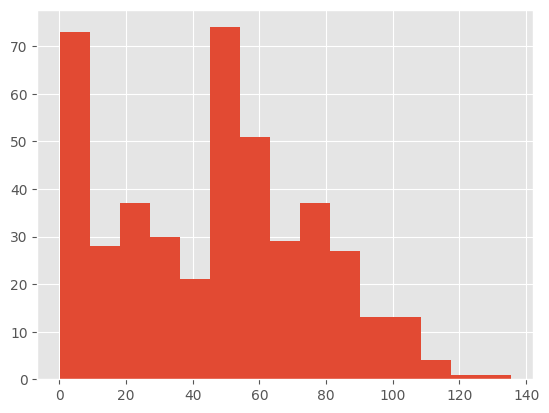

In [ ]:
data3['sumball'].hist(bins=15);

видим, что многие набрали 50 баллов. Но следует учесть, что этот балл - есть простая сумма баллов за задания. нам нужно вычислить сумму баллов с учетом только баллов успешно выполненных заданий (больше 60% от максимального балла)

Также несмотря нна то, что многи перевыполнили план и выполнили все обязательные и альтернативные задания и набрали более 100 баллов, им будут засчитано только 100 баллов (максимум за курс).


In [ ]:
# Calculate the maximum possible score for each column from the numeric data1 DataFrame
max_scores_from_data1 = data1.max()

# Initialize the new 'sum' column in data3 with zeros
data3['sum'] = 0.0

# Iterate over all columns in data3 to calculate the new 'sum'
for col in data3.columns:
    # Exclude the original 'sumball' column and the new 'sum' column itself from this calculation
    if col != 'sumball' and col != 'sum':
        # Get the maximum score for the current task from max_scores_from_data1.
        # Use a default of 5.0 if a max score is not found, consistent with the user's example.
        current_max_score = max_scores_from_data1.get(col, 5.0)

        # Calculate the 60% threshold for this specific task
        success_threshold = 0.6 * current_max_score

        # Apply the condition: add score if it's >= threshold, else add 0.
        # Fill NaN values with 0 before comparison and addition.
        data3['sum'] += data3[col].fillna(0).apply(lambda x: x if x >= success_threshold else 0)

# Display the head of data3 to show the new 'sum' column and compare with 'sumball'
data3.head()

,T:1.1.5.,T:1.2.9.,T:1.2.10.,VPL:1.2.11.,VPL:1.2.12.,VPL:1.2.13.,T:1.3.11.,T:1.3.12.,VPL:1.3.13.,VPL:1.3.14.,...,VPL:2.5.3.,T:3.0.5.,T:3.1.5.,T:4.1.7.,T:4.2.5.,sumball,VPL:РЕШЕНИЕ,VPL:Морское,T:ИТОГОВЫЙ,sum
0,1.00,1.33,5.0,0.0,0.0,0.0,1.0,4.5,0.0,0.0,...,0.0,0.00,0.0,0.0,0.0,13.58,0.0,0.0,0.0,9.50
1,0.76,0.83,5.0,0.0,0.0,0.0,2.0,4.5,0.0,0.0,...,0.0,0.33,0.0,1.5,2.0,19.30,0.0,0.0,1.0,11.50
4,2.63,5.00,5.0,5.0,5.0,5.0,5.0,5.0,5.0,2.0,...,0.0,0.00,0.0,0.0,0.0,69.96,0.0,0.0,0.0,65.00
5,2.18,2.50,5.0,5.0,5.0,5.0,4.0,4.0,5.0,2.0,...,6.0,0.00,0.0,0.0,0.0,101.86,0.0,9.0,12.5,81.25
6,0.00,0.17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.17,0.0,0.0,0.0,5.57,0.0,0.0,0.0,2.50


In [ ]:
# определяем студентов, удовлетворяющих условию сумма баллов больше или равна 50
cond_1 = (data3.loc[:, 'sum'] >= 50)
sum(cond_1)

180

In [ ]:
# делаем разметку студентов
data3['label'] = 0
data3.loc[cond_1, 'label'] = 1
data3.sample(7)

,T:1.1.5.,T:1.2.9.,T:1.2.10.,VPL:1.2.11.,VPL:1.2.12.,VPL:1.2.13.,T:1.3.11.,T:1.3.12.,VPL:1.3.13.,VPL:1.3.14.,...,T:3.0.5.,T:3.1.5.,T:4.1.7.,T:4.2.5.,sumball,VPL:РЕШЕНИЕ,VPL:Морское,T:ИТОГОВЫЙ,sum,label
560,2.08,4.0,4.5,3.0,5.0,5.0,4.5,5.0,5.0,0.0,...,0.0,0.0,0.0,0.0,55.28,0.0,0.0,0.0,50.00,1
67,2.38,3.5,5.0,3.0,5.0,5.0,4.0,5.0,5.0,2.0,...,0.0,0.0,0.0,0.0,76.88,0.0,0.0,0.0,70.26,1
479,1.90,4.5,5.0,3.0,5.0,5.0,4.5,5.0,5.0,2.0,...,0.0,0.0,0.0,0.0,60.73,0.0,0.0,0.0,56.33,1
507,3.00,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,2.0,...,0.0,0.0,0.0,0.0,79.50,0.0,9.0,0.0,76.50,1
435,2.63,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,2.0,...,0.0,0.0,0.0,0.0,44.63,0.0,0.0,0.0,42.00,0
83,2.83,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,2.0,...,0.0,0.0,0.0,0.0,80.87,1.0,10.0,0.0,71.38,1
78,0.70,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.19,0.0,0.0,0.0,0.00,0


### **Корректировка балла и анализ разметка**

Скорректируем балл в подготовленных для обучения модели даннных. Проанализируем количественный состав каждого из классов

In [ ]:
data4['sumball'] = data3['sum']
data4['label'] = data3['label']
data4.describe()

/tmp/ipykernel_34921/2109946443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data4['sumball'] = data3['sum']
/tmp/ipykernel_34921/2109946443.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data4['label'] = data3['label']


,T:1.1.5.,T:1.2.9.,T:1.2.10.,VPL:1.2.11.,VPL:1.2.12.,VPL:1.2.13.,T:1.3.11.,T:1.3.12.,VPL:1.3.13.,VPL:1.3.14.,VPL:1.3.15.,VPL:1.3.16.,T:1.4.11.,T:1.4.12.,VPL:1.4.13.,VPL:1.4.14.,VPL:1.4.15.,sumball,label
count,439.000000,439.000000,439.000000,439.000000,439.000000,439.00000,439.000000,439.000000,439.000000,439.000000,439.000000,439.000000,439.000000,439.000000,439.000000,439.000000,439.000000,443.000000,443.000000
mean,2.218610,3.850137,4.051253,3.275626,3.061503,3.15262,3.500592,3.561139,2.939636,1.061503,1.129841,0.964692,2.785239,1.825626,1.018223,0.824601,0.801822,41.541738,0.406321
std,0.798766,1.733217,1.841057,2.346497,2.359930,2.36642,2.012404,2.093211,2.445129,0.980797,1.447403,1.398958,1.977328,1.440565,1.422146,1.328898,1.322667,28.446212,0.491701
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.910000,3.500000,4.500000,0.000000,0.000000,0.00000,2.500000,1.710000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.000000,0.000000
50%,2.400000,4.830000,5.000000,5.000000,5.000000,5.00000,4.500000,5.000000,5.000000,2.000000,0.000000,0.000000,3.580000,2.500000,0.000000,0.000000,0.000000,45.100000,0.000000
75%,2.770000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,2.000000,3.000000,3.000000,4.500000,3.080000,3.000000,3.000000,3.000000,62.590000,1.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,3.000000,3.000000,3.000000,5.000000,5.000000,3.000000,3.000000,3.000000,121.550000,1.000000


In [ ]:
ts = pd.Series(data4['label'])
ts.value_counts()

,count
label,
0.0,263
1.0,180


### **Запись в файл подготовленных исходных данных**
---

Подготовленные данные надо записать в файл. Имя можно взять исходное и к нему сделать приписку _tiny или что-то другое, что объясняет содержимое

In [ ]:
# сохраняем в файл только с частью исходных данных, без нескольких последних результатов
out_file2 = dir_path + course_file_name + "_part1_tiny.csv"
data4.to_csv(out_file2, index=False, sep=';')

Таким образом мы подготовили данные для решения задачи классификации пользователей на тех, кто не завершил курс или завершил его успешно в зависимости от результатов выполнения первых заданий курса.

-----------


## **3. Строим базовые прогнозаторы - регрессионную зависимость для прогноза суммарного балла и классификатор (baseline)**
---

### **Загрузка и формирование массивов входных - выходных данных**

In [ ]:
# **3.1 Загружаем данные из файла**
datafile = dir_path + course_file_name + "_part1_tiny.csv"
data_3 = pd.read_csv(datafile, sep=";")
data_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 444 entries, 0 to 443
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   T:1.1.5.     439 non-null    float64
 1   T:1.2.9.     439 non-null    float64
 2   T:1.2.10.    439 non-null    float64
 3   VPL:1.2.11.  439 non-null    float64
 4   VPL:1.2.12.  439 non-null    float64
 5   VPL:1.2.13.  439 non-null    float64
 6   T:1.3.11.    439 non-null    float64
 7   T:1.3.12.    439 non-null    float64
 8   VPL:1.3.13.  439 non-null    float64
 9   VPL:1.3.14.  439 non-null    float64
 10  VPL:1.3.15.  439 non-null    float64
 11  VPL:1.3.16.  439 non-null    float64
 12  T:1.4.11.    439 non-null    float64
 13  T:1.4.12.    439 non-null    float64
 14  VPL:1.4.13.  439 non-null    float64
 15  VPL:1.4.14.  439 non-null    float64
 16  VPL:1.4.15.  439 non-null    float64
 17  sumball      443 non-null    float64
 18  label        443 non-null    float64
dtypes: float

In [ ]:
data_3 = data_3.fillna(0.0)

# Выделяем входные и выходные параметры в отдельные массивы
X = data_3.values[:, 0:-2]
y = data_3['sumball']
labels = data_3['label']

X.shape, y.shape, labels.shape

((444, 17), (444,), (444,))

### **Предварительный анализ и оценка зависимостей**

In [ ]:
# Выберем часть столбцов для визуального анализа их завитсимости с суммой баллов
lasttasks = list(data_3.columns[-10:])
lasttasks

['VPL:1.3.14.',
 'VPL:1.3.15.',
 'VPL:1.3.16.',
 'T:1.4.11.',
 'T:1.4.12.',
 'VPL:1.4.13.',
 'VPL:1.4.14.',
 'VPL:1.4.15.',
 'sumball',
 'label']

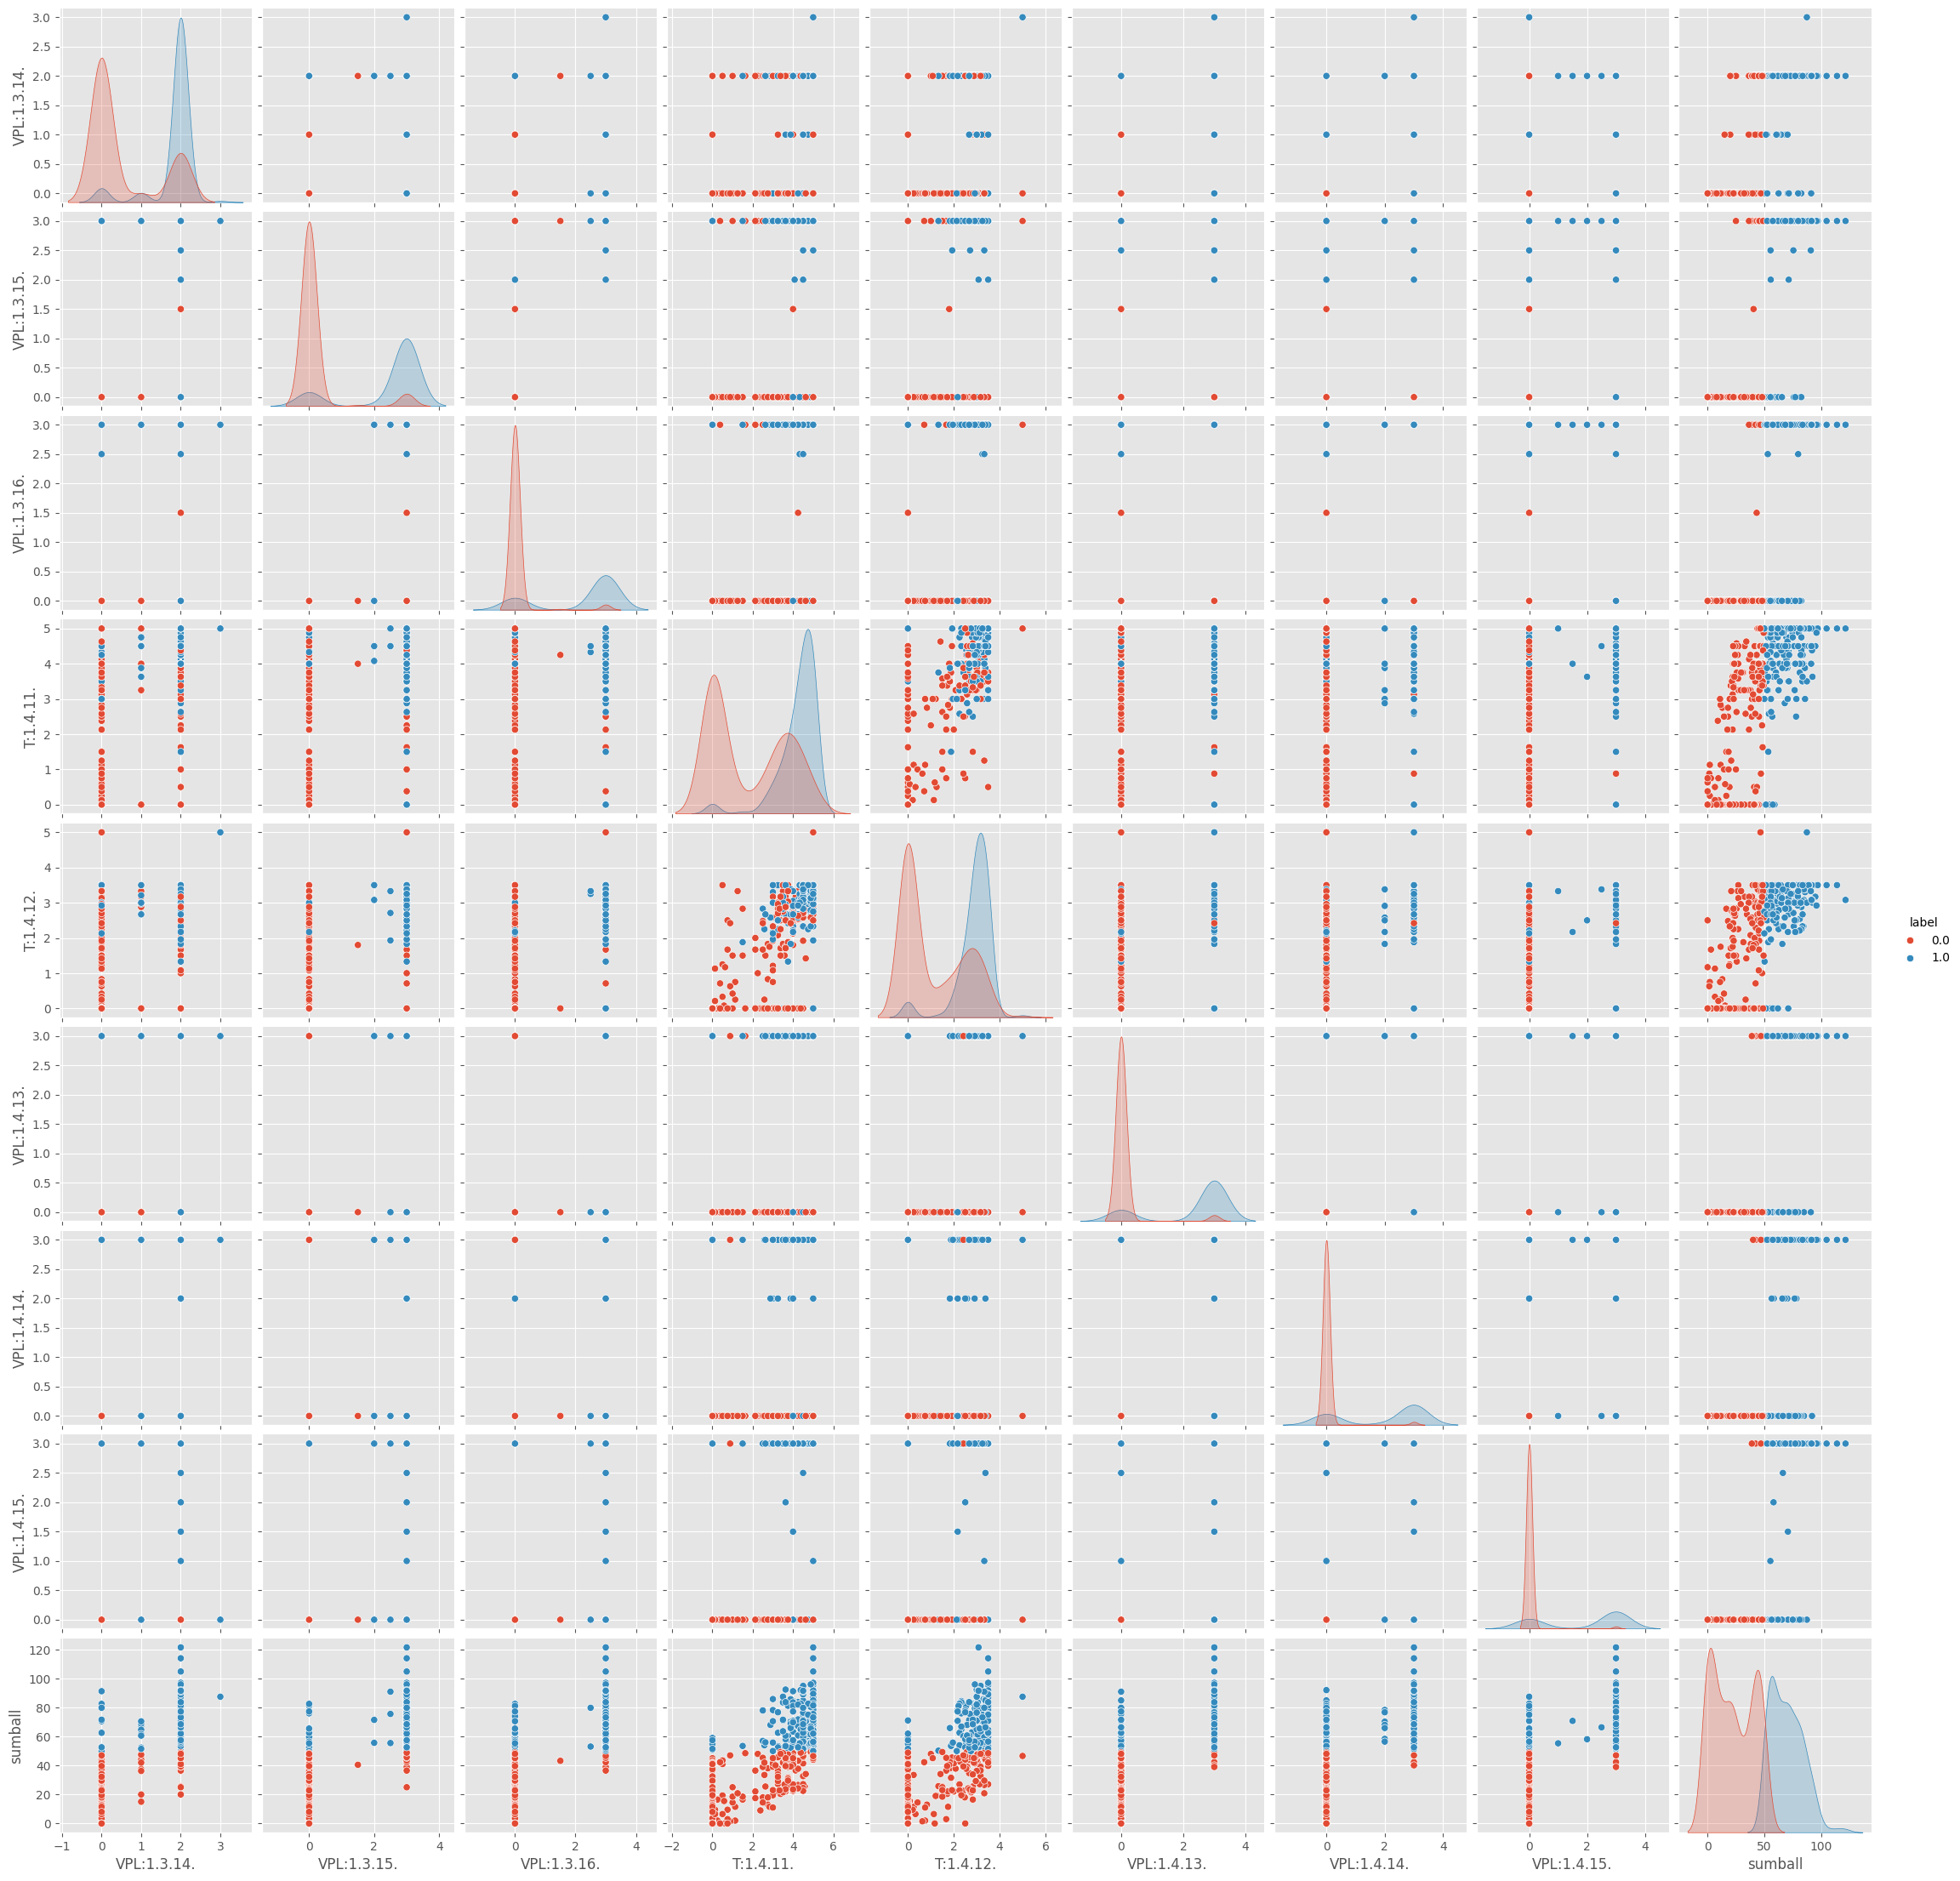

In [ ]:
import seaborn as sns

sns.pairplot(data_3[lasttasks], hue='label');

визцально видна статистическая зависимость итогового балла от баллов за отдельные задания курса

### **3.1. Строим линейную регрессионную зависимость**
---

Используем кросс-валидацию для построения линейной зависимости. Но прежде чем применить кросс-валидацию необходимо разделить выборку на обучающую и тестовую.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# Get the indices of the full dataset
indices = np.arange(len(X))

# Split X, y, and their corresponding indices
x_train, x_test, y_train, y_test, labels_train, labels_test, train_indices, test_indices = train_test_split(
    X, y, labels, indices, test_size=0.25, random_state=42
)

print(f"Train indices shape: {train_indices.shape}")
print(f"Test indices shape: {test_indices.shape}")

Train indices shape: (333,)
Test indices shape: (111,)


### **3.3. Построение простой линейной регрессии без дополнительных предикторов**
--------

Т.е. будем строить простую модель вида:

$$y_m(t) = a_0 + a_1*x_1 + ...+ a_k*x_k$$


In [ ]:
from sklearn.linear_model import LinearRegression
# здесь Ваш код ...
lr = LinearRegression()
lr_model = lr.fit(x_train, y_train)

print('a0=', lr_model.intercept_)
print(lr_model.coef_)

a0= -1.6169070234371645
[0.881 1.466 0.154 1.426 1.965 0.158 1.909 0.08  0.183 0.635 2.362 0.301
 1.547 1.704 1.131 1.695 4.019]


### **3.4. Проанализируем полученную модель**
---

Оценим ее точность на тестовой выборке

MAE =  5.225136892766479
MSE =  59.813447074150574
r2_score = 0.9246466914362264


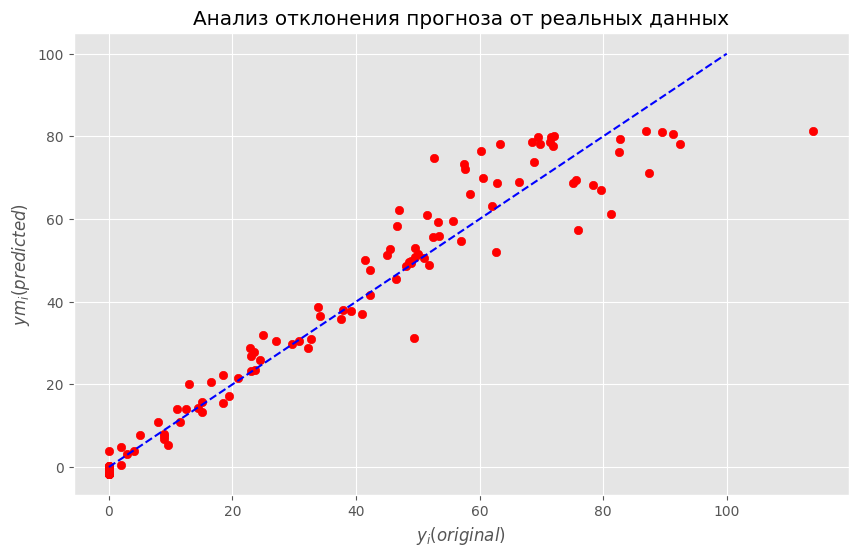

In [ ]:
from sklearn import metrics

y_predicted = lr_model.predict(x_test)
print('MAE = ', metrics.mean_absolute_error(y_test, y_predicted))
print('MSE = ', metrics.mean_squared_error(y_test, y_predicted))
print('r2_score =', metrics.r2_score(y_test, y_predicted))

fig = plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_predicted, c = 'r', marker = 'o', label = 'predicted-original')
plt.xlabel('$y_i(original)$'), plt.ylabel('$ym_i(predicted)$')
plt.plot([0, 100], [0, 100], 'b--')
plt.title('Анализ отклонения прогноза от реальных данных');

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# точность прогноза тех, кто успешно завершит обучение
labels_predicted = y_predicted >= 50
print("accuracy = {:.4f}".format(accuracy_score(labels_test, labels_predicted)))
print('f1_score=', f1_score(labels_test, labels_predicted))

sum(labels_predicted), sum(labels_test)

accuracy = 0.9189
f1_score= 0.898876404494382


(np.int64(48), 41.0)

# Задания для студентов:

### **1. Пробуем улучшить модель**
---
Попробуйте улучшить полученную модель. Повысить r2_score или уменьшить MAE на тестовой выборке.

Чтобы улучшить модель можно попробовать:

- использовать L1, L2- регуляризацию;
- использовать кросс-валидацию;
- добавить полиномиальные предикторы;
- добавить для каждого начального признака Xi логический признак Zi = (Xi >= 0.6 * max(Xi));
- оценить важность признаков для модели с логическими признаками;
- скомбинировать исходные и логические признаки, умножив друг на друга (баллы ниже 50% от максимума не суммируются при подсчете итогового балла);
- оценить важность признаков для модели с комбинированными признаками;
- потюнить параметры модели

### 2. AutoML

используйте пакет auto-sklearn чтобы улучшить результаты

## 3. Выводы
Cделайте и опишите выводы по проведенному исследованию